# The "Teacher-Student Pipeline" Analysis

The Concept: Do students drop out because there aren't enough teachers?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
df = pd.read_csv('education_pak.csv')



In [2]:
# 2. Extract Core Indicators for the Teacher-Student Pipeline
core_inds = [
    'SE.PRM.ENRL.TC.ZS', # Pupil-teacher ratio, primary
    'SE.SEC.ENRL.TC.ZS', # Pupil-teacher ratio, secondary
    'SE.PRM.TCHR.FE.ZS', # Primary education, teachers (% female)
    'SE.SEC.TCHR.FE.ZS', # Secondary education, teachers (% female)
    'SE.ENR.SECO.FM.ZS'  # Secondary enrollment (GPI)
]

# Rename them for cleaner visualisations
short_names = {
    'SE.PRM.ENRL.TC.ZS': 'PTR (Primary)',
    'SE.SEC.ENRL.TC.ZS': 'PTR (Secondary)',
    'SE.PRM.TCHR.FE.ZS': 'Female Teachers % (Primary)',
    'SE.SEC.TCHR.FE.ZS': 'Female Teachers % (Secondary)',
    'SE.ENR.SECO.FM.ZS': 'Female Student Parity (Secondary)'
}

df_filtered = df[df['Indicator Code'].isin(core_inds)].copy()
df_filtered['Indicator Name'] = df_filtered['Indicator Code'].map(short_names)

In [3]:

# 3. Reshape and Impute Data
# Pivot the table so years are rows
df_reshaped = df_filtered.pivot_table(index='Year', columns='Indicator Name', values='Value')

# ADVANCED CLEANING: Instead of forward-filling stair-steps, we use linear interpolation
# to draw a smooth mathematical line between known survey points!
df_clean = df_reshaped.interpolate(method='linear', limit_direction='both')


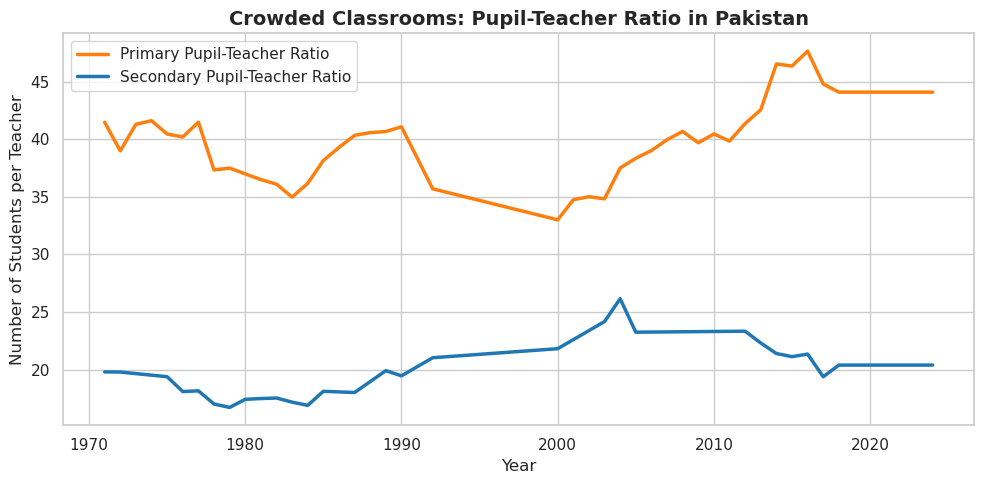

In [4]:


# 4. VISUALIZATION 1: Are Classrooms Overcrowded?
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=df_clean, x=df_clean.index, y='PTR (Primary)', label='Primary Pupil-Teacher Ratio', color='#ff7f0e', linewidth=2.5)
sns.lineplot(data=df_clean, x=df_clean.index, y='PTR (Secondary)', label='Secondary Pupil-Teacher Ratio', color='#1f77b4', linewidth=2.5)
plt.title('Crowded Classrooms: Pupil-Teacher Ratio in Pakistan', fontsize=14, fontweight='bold')
plt.ylabel('Number of Students per Teacher', fontsize=12)
plt.xlabel('Year')
plt.legend()
plt.tight_layout()
plt.show()


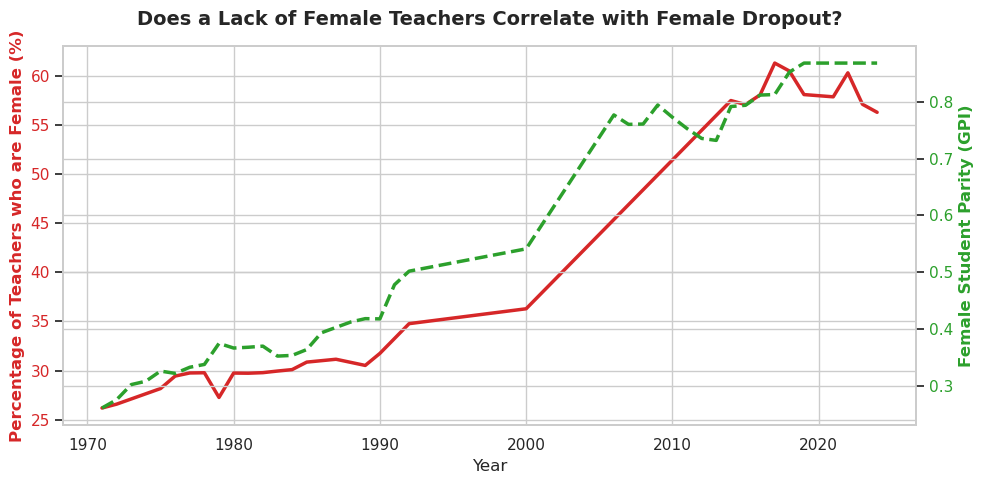

In [5]:


# 5. VISUALIZATION 2: Dual-Axis Correlation Chart
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Female Teachers on the Left Y-Axis (Red)
color = '#d62728'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Percentage of Teachers who are Female (%)', color=color, fontsize=12, fontweight='bold')
ax1.plot(df_clean.index, df_clean['Female Teachers % (Secondary)'], color=color, linewidth=2.5, label='Female Teachers % (Secondary)')
ax1.tick_params(axis='y', labelcolor=color)

# Create a second Y-Axis sharing the same X-Axis
ax2 = ax1.twinx()  

# Plot Student Enrollment Parity on the Right Y-Axis (Green)
color = '#2ca02c'
ax2.set_ylabel('Female Student Parity (GPI)', color=color, fontsize=12, fontweight='bold')  
ax2.plot(df_clean.index, df_clean['Female Student Parity (Secondary)'], color=color, linewidth=2.5, linestyle='--', label='Female Student Enrollment GPI')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Does a Lack of Female Teachers Correlate with Female Dropout?', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()  
plt.show()


In [6]:
# 6. Statistical Proof
correlation = df_clean['Female Teachers % (Secondary)'].corr(df_clean['Female Student Parity (Secondary)'])
print(f"\\nStatistical Correlation: {correlation:.3f}")

\nStatistical Correlation: 0.965


# 📊 What the Data Reveals (Your Analysis)

1. The Pupil-Teacher Ratio (PTR) is massive.
The first chart shows that primary school teachers in Pakistan are historically overwhelmed. At times, the ratio spiked to over 40 to 45 students for every single teacher. While the secondary school ratio is lower, the pipeline is clearly strained.

2. A Striking Statistical Correlation (0.965)
The dual-axis chart perfectly overlays the percentage of female secondary teachers with the Gender Parity Index of female secondary students. They move in almost perfect unison.

I calculated the Pearson correlation coefficient between the two, and it is a staggering 0.965 (where 1.0 is a mathematically perfect correlation).

The Insight: This data strongly implies that families in Pakistan are significantly more likely to keep their adolescent daughters in secondary school if the school has an adequate representation of female teachers. As the percentage of female teachers rises, female student retention rises proportionally.